### Dependencias y Carga

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

df = pd.read_csv('songs.csv', nrows=499000, encoding='latin1') #Las últimas filas tienen errores


### Procesamiento

In [7]:
# solo tomamos la valencia y los años
df = df.dropna(subset=['year', 'valence'])

# only entre 1970 a 2023
df = df[(df['year']>=1970) & (df['year']<=2023)]

# promediamos por año
promedio_anual = df.groupby('year')['valence'].mean().reset_index()

# almacenamos en matriz.
valencia = promedio_anual['valence'].values.reshape(1,-1)



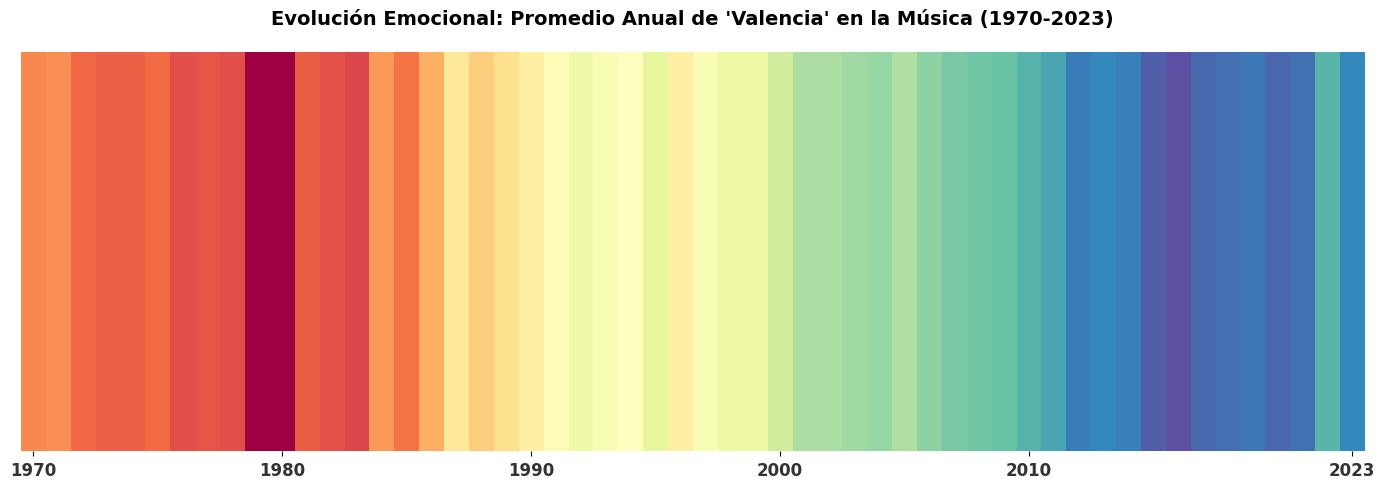

In [13]:
fig, ax = plt.subplots(figsize=(14,5))

# en reversa para que calze bien la evolución
# rojo = mayor valencia
# azul = menor valencia
cmap = plt.get_cmap('Spectral_r') 
img = ax.imshow(valencia, cmap=cmap, aspect='auto', vmin=valencia.min(), vmax=valencia.max())

ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)


# solo años clave en eje x
años = promedio_anual['year'].values

ax.set_xticks([0, 10, 20, 30, 40, len(años)-1]) # Índices de las décadas aproximadas
ax.set_xticklabels([años[0], años[10], años[20], años[30], años[40], años[-1]], fontsize=12, fontweight='bold', color='#333333')

plt.title("Evolución Emocional: Promedio Anual de 'Valencia' en la Música (1970-2023)", fontsize=14, pad=20, fontweight='bold')

plt.tight_layout()
plt.show()